In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append("..")

import numpy as np
import torch

from src.distributions import StandardNormalSampler, SwissRollSampler
from src.light_gcot import LightGCOT
from src.plotting import plot_A_parameters, plot_B_parameters, plot_distributions

In [3]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [11]:
torch.set_default_device(device)

In [25]:
models = []
n_potentials = 500
m_potentials = 25
epsilon = 0.002
exp_cost = "MLP"
exp_cost_included = True
exp_meta_info = "_c(x,y)=||x+y||^2_rand"
max_steps = 20000

for eps in [epsilon]:
    EXP_NAME = (
        f"LightGCOT_Swiss_Roll_EPSILON_{eps}_MAX_STEPS_{max_steps}_N_{n_potentials}_M_{m_potentials}_with_{exp_cost}_cost_included_{exp_cost_included}"
        + exp_meta_info
    )
    OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)
    D = LightGCOT(
        x_dim=2,
        y_dim=2,
        n_potentials=n_potentials,
        m_potentials=m_potentials,
        epsilon=eps,
        A_diagonal_init=0.1,
        cost_function=exp_cost,
    )
    D.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_{max_steps}.pt")))
    models.append(D)

In [13]:
X_sampler = StandardNormalSampler(dim=2, device="cuda")
Y_sampler = SwissRollSampler(dim=2, device="cuda")

In [14]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## Plotting

In [17]:
starting_points = torch.tensor([[-1.5, 1.5], [0.0, 0.0], [1.5, -1.5]])

/beegfs/home/m.persiyanov/Light-GCOT/src/plotting.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc="lower right")


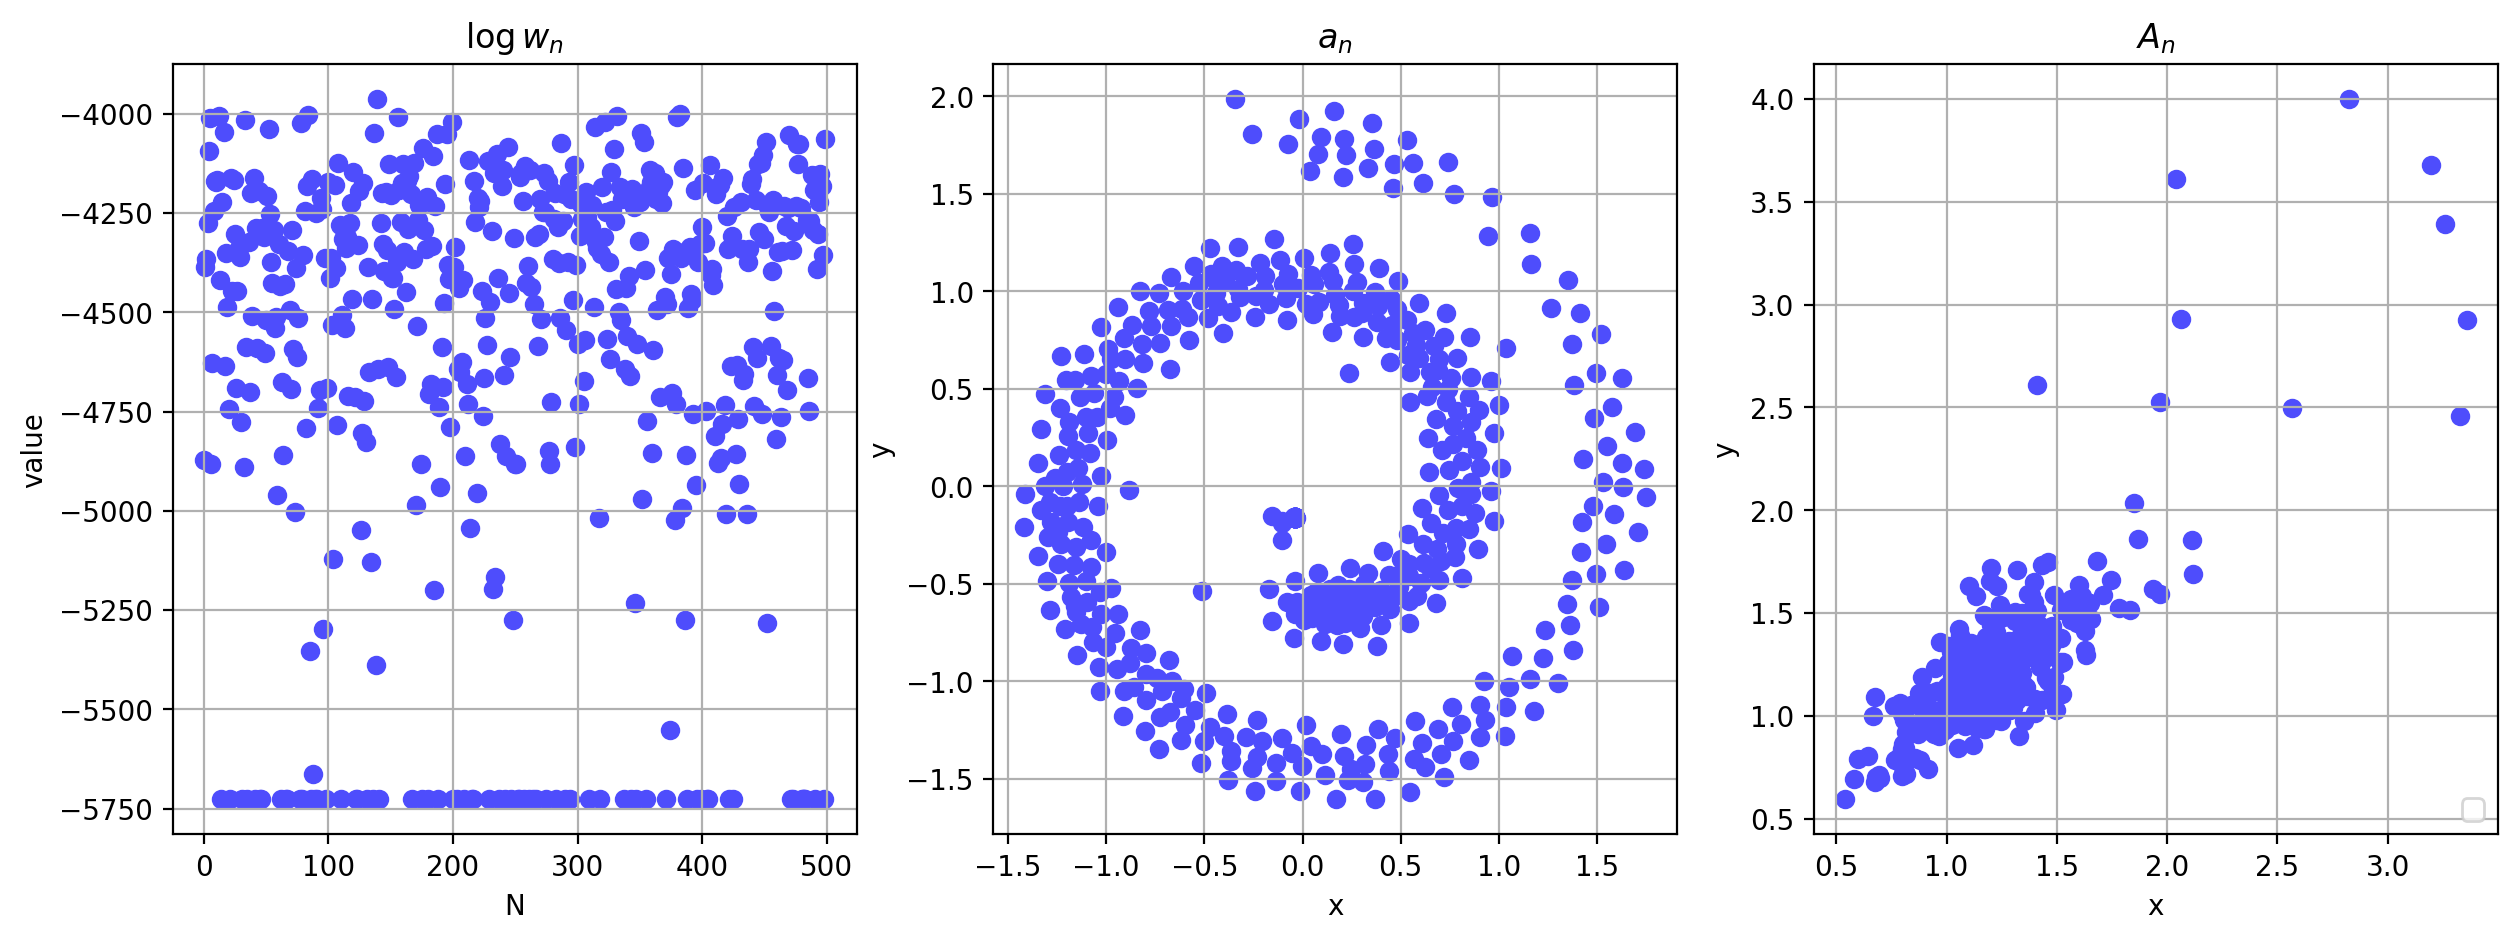

In [19]:
plot_A_parameters(D)

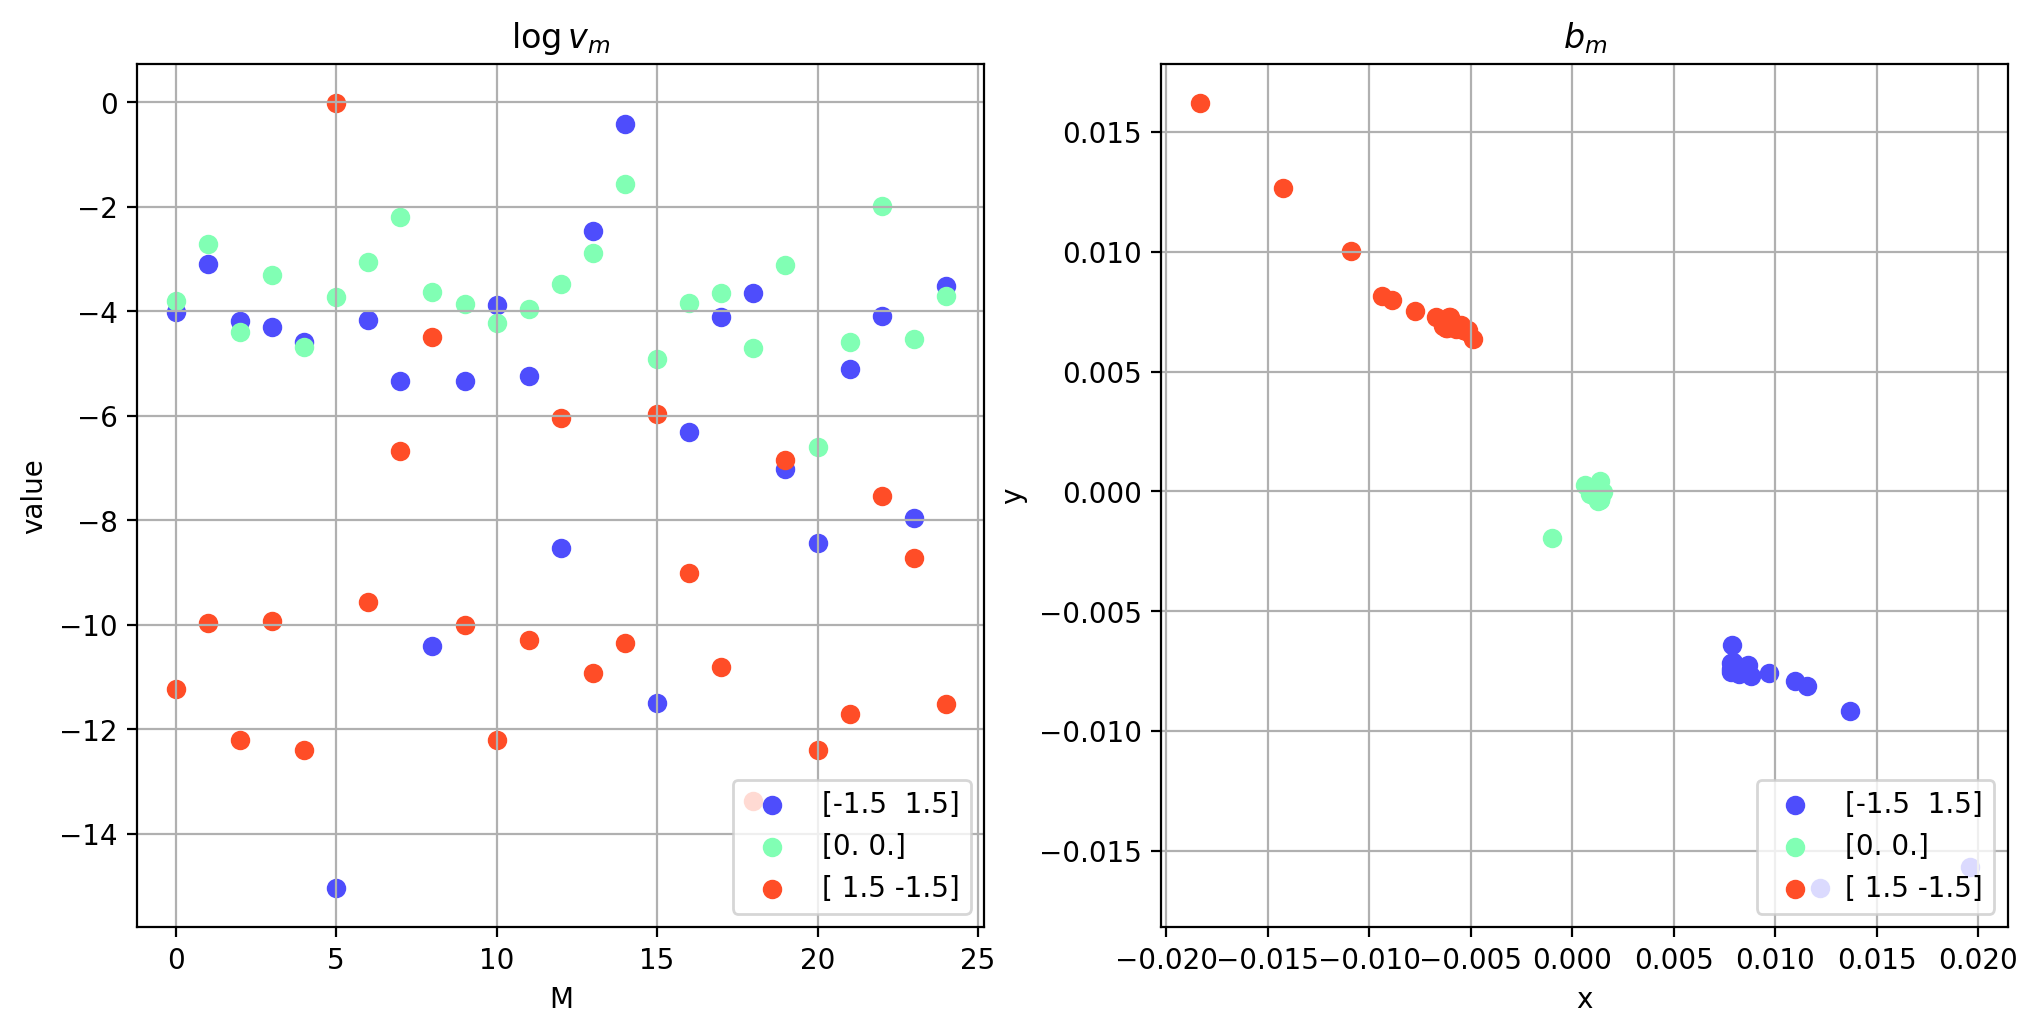

In [24]:
plot_B_parameters(D, starting_points)

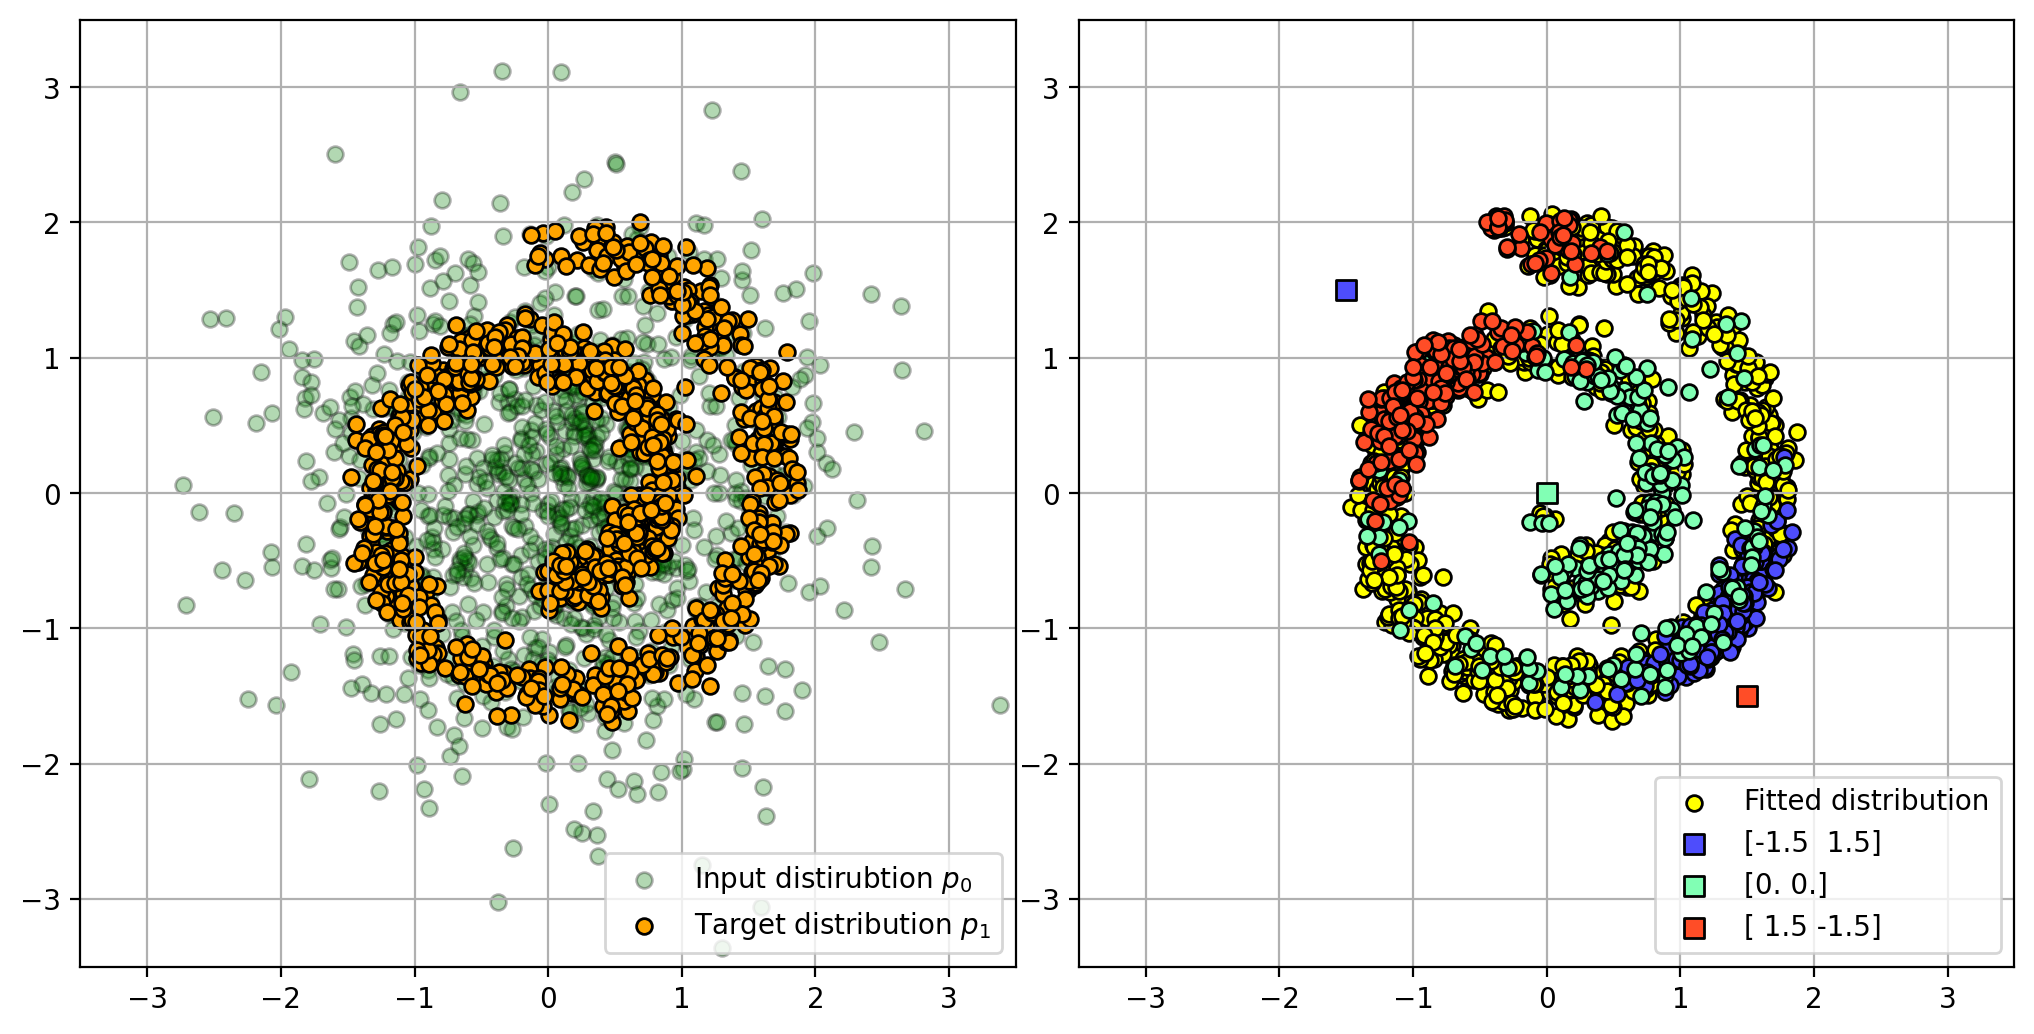

In [26]:
plot_distributions(D, X_sampler, Y_sampler, starting_points)